# Experiment: Hyperparameter Optimization for Jaguar Re-Identification

This notebook builds on the **baseline pipeline** (MegaDescriptor + ArcFace) and performs a **systematic hyperparameter analysis** to find the best configuration.

## Hypothesis
Tuning key hyperparameters — learning rate schedule, optimizer, embedding/hidden dimensions, and ArcFace margin/scale — will improve validation mAP compared to the baseline defaults.

## Hyperparameter Sweeps
1. **Learning Rate Schedules** — ReduceLROnPlateau (baseline), CosineAnnealingLR, StepLR, OneCycleLR
2. **Optimizer Comparisons** — Adam, SGD (with momentum), AdamW (baseline), Muon
3. **Embedding Dimension & Hidden Layer Sizes** — vary `embedding_dim` and `hidden_dim`
4. **ArcFace Margin & Scale** — vary angular margin `m` and feature scale `s`

## Methodology
- Each sweep trains a fresh model for **20 epochs** (reduced from 50) to efficiently compare configurations
- The **best overall configuration** is then trained for the full 50 epochs
- All metrics are logged to W&B for dashboard comparison

## Comparability to Baseline
- Same MegaDescriptor-L-384 backbone
- Same train/val split (stratified, seed=42)
- Same validation mAP computation
- Same data (no augmentation — same as baseline)
- **Only difference**: Hyperparameters being swept

## 1. Setup and Configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import copy
import json
import wandb
from dotenv import load_dotenv

# Load environment variables from .env file
env_path = Path("../../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"] = user_secrets.get_secret("hf_api")
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")
except ImportError:
    print("Not running on Kaggle, using local .env for secrets.")

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

PyTorch version: 2.9.0+cu126
timm version: 1.0.24
Using CUDA GPU
Device: cuda


In [2]:
# ── Base Configuration (IDENTICAL to baseline) ──
base_config = {
    # Paths
    "data_dir": Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints_hyperopt"),

    # Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "embedding_dim": 256,
    "hidden_dim": 512,

    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,

    # Reproducibility
    "seed": RANDOM_SEED,
}

# ── Sweep settings ──
SWEEP_EPOCHS = 20          # reduced epochs for sweep runs
SWEEP_PATIENCE = 7         # reduced patience for sweep runs
FULL_TRAIN_EPOCHS = 50     # full epochs for the best configuration

# Create checkpoint directory
base_config["checkpoint_dir"].mkdir(exist_ok=True)

print("Base Configuration (same as baseline):")
for key, value in base_config.items():
    print(f"  {key}: {value}")
print(f"\nSweep settings:")
print(f"  Sweep epochs: {SWEEP_EPOCHS}")
print(f"  Sweep patience: {SWEEP_PATIENCE}")
print(f"  Full train epochs: {FULL_TRAIN_EPOCHS}")

Base Configuration (same as baseline):
  data_dir: /kaggle/input/competitions/jaguar-re-id
  checkpoint_dir: checkpoints_hyperopt
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  seed: 42

Sweep settings:
  Sweep epochs: 20
  Sweep patience: 7
  Full train epochs: 50


In [3]:
# Initialize W&B
wandb.login(key=os.environ["WANDB_API_KEY"])
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "Jaguar-Re-identification-Challenge")
print(f"W&B project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: finnfrei (finnfreiheit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B project: Jaguar-Re-identification-Challenge


## 2. Load and Prepare Data

In [4]:
# Load training data
train_df = pd.read_csv(base_config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

# Analyze identity distribution
identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min images per identity: {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max images per identity: {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean images per identity: {identity_counts.mean():.1f}")

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min images per identity: 13 (Ipepo)
  Max images per identity: 183 (Marcela)
  Mean images per identity: 61.1


In [5]:
# Encode labels and create stratified train/validation split
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size=base_config["val_split"],
    random_state=base_config["seed"],
    stratify=train_df['ground_truth']
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-base_config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*base_config['val_split']:.0f}%)")
print(f"  Num classes: {num_classes}")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())
assert train_identities == val_identities, "Not all identities in both sets!"
print(f"  All {len(train_identities)} identities present in both sets ✓")

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)
  Num classes: 31
  All 31 identities present in both sets ✓


## 3. Load MegaDescriptor and Extract Embeddings

In [6]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    base_config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)

print(f"Model loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in megadescriptor.parameters()):,}")

# Get the embedding dimension from the model
with torch.no_grad():
    dummy_input = torch.randn(1, 3, base_config["input_size"], base_config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Model loaded successfully
  Parameters: 195,198,516
  Embedding dimension: 1536


In [7]:
# Preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((base_config["input_size"], base_config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using MegaDescriptor."""
    model.eval()
    embeddings = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]

        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                batch_tensors.append(torch.zeros(3, base_config["input_size"], base_config["input_size"]))

        batch_tensor = torch.stack(batch_tensors).to(device)
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)

    return np.vstack(embeddings)

print("Embedding extraction function defined")

Embedding extraction function defined


In [8]:
# Extract and cache embeddings for training and validation sets

# Training embeddings
train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [base_config["data_dir"] / "train/train" / fn for fn in train_filenames]

emb_dir = Path("/kaggle/working/embeddings")
emb_dir.mkdir(parents=True, exist_ok=True)
cache_path = emb_dir / "hyperopt_train_embeddings.npz"

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])
    if len(cached_filenames) != len(expected_filenames):
        return None
    if set(cached_filenames) != set(expected_filenames):
        return None
    if cached_filenames == expected_filenames:
        return cached_embeddings
    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

baseline_train_embeddings = None
if cache_path.exists():
    baseline_train_embeddings = _load_cached_embeddings(cache_path, train_filenames)
    if baseline_train_embeddings is not None:
        print(f"Loaded cached train embeddings from {cache_path}")

if baseline_train_embeddings is None:
    print(f"Extracting embeddings for {len(train_image_paths)} training images...")
    baseline_train_embeddings = extract_embeddings(
        megadescriptor, train_image_paths, batch_size=base_config["batch_size"]
    )
    np.savez_compressed(cache_path, embeddings=baseline_train_embeddings, filenames=np.array(train_filenames, dtype=object))
    print(f"Saved train embeddings cache to {cache_path}")

print(f"Train embeddings shape: {baseline_train_embeddings.shape}")

# Validation embeddings
val_image_paths = [base_config["data_dir"] / "train/train" / fn for fn in val_data['filename'].values]

print(f"Extracting embeddings for {len(val_image_paths)} validation images...")
baseline_val_embeddings = extract_embeddings(
    megadescriptor, val_image_paths, batch_size=base_config["batch_size"]
)
print(f"Val embeddings shape: {baseline_val_embeddings.shape}")

Extracting embeddings for 1516 training images...


Extracting embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Saved train embeddings cache to /kaggle/working/embeddings/hyperopt_train_embeddings.npz
Train embeddings shape: (1516, 1536)
Extracting embeddings for 379 validation images...


Extracting embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Val embeddings shape: (379, 1536)


## 4. Define Model Architecture (IDENTICAL to Baseline)

In [9]:
class EmbeddingProjection(nn.Module):
    """Projects MegaDescriptor embeddings to a lower-dimensional space."""

    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """ArcFace (Additive Angular Margin Loss) layer."""

    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)

        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale

        return output


class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""

    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512,
                 margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout,
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim,
            num_classes=num_classes,
            margin=margin,
            scale=scale,
        )

    def forward(self, x, labels):
        embeddings = self.embedding_net(x)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings

    def get_embeddings(self, x):
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)


print("Model architecture defined (EmbeddingProjection, ArcFaceLayer, ArcFaceModel)")

Model architecture defined (EmbeddingProjection, ArcFaceLayer, ArcFaceModel)


## 5. Training Utilities

In [10]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""

    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


def compute_validation_map(model, val_embeddings, val_labels, device):
    """
    Compute identity-balanced mean Average Precision on validation set.
    IDENTICAL to baseline.
    """
    model.eval()

    with torch.no_grad():
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()

    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)

    query_aps = {}

    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        similarities = sim_matrix[query_idx]

        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0

        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]

        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue

        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives

        query_aps[query_idx] = (query_label, ap)

    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)

    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)

    return balanced_map


def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for embeddings, labels in loader:
        embeddings, labels = embeddings.to(device), labels.to(device)

        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for embeddings, labels in loader:
            embeddings, labels = embeddings.to(device), labels.to(device)

            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training utilities defined")

Training utilities defined


In [11]:
# ── Muon Optimizer Implementation ──
# Muon (Momentum Orthogonalized Update) is a recent optimizer that applies
# Newton-Schulz orthogonalization to the momentum buffer for faster convergence.

def newton_schulz_(M, max_iter=5, eps=1e-7):
    """In-place Newton-Schulz iteration to approximate M @ (M^T M)^{-1/2}."""
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = M.double() / (M.norm().double() + eps)
    if X.ndim < 2:
        return
    for _ in range(max_iter):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    M.copy_(X.to(M.dtype))


class Muon(torch.optim.Optimizer):
    """
    Muon optimizer – Momentum with Newton-Schulz orthogonalization.

    Only orthogonalizes parameters with ndim >= 2 (weight matrices).
    1D parameters (biases, BN) are updated with standard SGD+momentum.

    Args:
        params: model parameters
        lr: learning rate (default: 0.02)
        momentum: momentum factor (default: 0.95)
        weight_decay: weight decay (default: 0)
        ns_iter: Newton-Schulz iterations (default: 5)
    """

    def __init__(self, params, lr=0.02, momentum=0.95, weight_decay=0.0, ns_iter=5):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay, ns_iter=ns_iter)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            momentum = group["momentum"]
            wd = group["weight_decay"]
            ns_iter = group["ns_iter"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad

                if wd != 0:
                    g = g.add(p, alpha=wd)

                state = self.state[p]
                if len(state) == 0:
                    state["buf"] = torch.zeros_like(g)

                buf = state["buf"]
                buf.mul_(momentum).add_(g)

                if p.ndim >= 2:
                    update = buf.clone()
                    # Reshape to 2D for orthogonalization
                    original_shape = update.shape
                    if update.ndim > 2:
                        update = update.reshape(update.shape[0], -1)
                    newton_schulz_(update, max_iter=ns_iter)
                    if update.ndim != len(original_shape):
                        update = update.reshape(original_shape)
                    p.add_(update, alpha=-lr)
                else:
                    p.add_(buf, alpha=-lr)

        return loss


print("Muon optimizer defined")

Muon optimizer defined


## 6. Hyperparameter Sweep Runner

A generic function that trains a model with a given configuration and returns results. Each run gets its own W&B run for comparison.

In [12]:
def run_single_experiment(
    experiment_name,
    sweep_group,
    config_overrides,
    train_embeddings,
    train_labels,
    val_embeddings,
    val_labels_gt,
    val_labels_encoded,
    num_classes,
    megadescriptor_dim,
    device,
    num_epochs=SWEEP_EPOCHS,
    patience=SWEEP_PATIENCE,
):
    """
    Train one model with specific hyperparameters and return results.

    Args:
        experiment_name: name for the W&B run
        sweep_group: W&B group name (e.g. "lr_schedule", "optimizer")
        config_overrides: dict of hyperparameter overrides on top of base_config
        train_embeddings: numpy array of training embeddings
        train_labels: numpy array of encoded training labels
        val_embeddings: numpy array of validation embeddings
        val_labels_gt: numpy array of ground truth validation labels (strings)
        val_labels_encoded: numpy array of encoded validation labels
        num_classes: number of classes
        megadescriptor_dim: MegaDescriptor embedding dimension
        device: torch device
        num_epochs: number of training epochs
        patience: early stopping patience

    Returns:
        dict with best_val_map, best_val_loss, best_epoch, history
    """
    # Merge config
    cfg = {**base_config, **config_overrides}

    # Seed for reproducibility
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # Initialize W&B run
    run = wandb.init(
        project=WANDB_PROJECT,
        group=f"hyperopt-{sweep_group}",
        config={k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()},
        name=experiment_name,
        reinit=True,
    )

    # Create model
    model = ArcFaceModel(
        input_dim=megadescriptor_dim,
        num_classes=num_classes,
        embedding_dim=cfg["embedding_dim"],
        hidden_dim=cfg["hidden_dim"],
        margin=cfg["arcface_margin"],
        scale=cfg["arcface_scale"],
        dropout=cfg["dropout"],
    ).to(device)

    # Create dataloaders
    train_dataset = EmbeddingDataset(train_embeddings, train_labels)
    val_dataset = EmbeddingDataset(val_embeddings, val_labels_encoded)

    train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

    # Loss
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer_name = cfg.get("optimizer_name", "AdamW")
    lr = cfg["learning_rate"]
    wd = cfg["weight_decay"]

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif optimizer_name == "Muon":
        optimizer = Muon(model.parameters(), lr=lr, momentum=0.95, weight_decay=wd)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Scheduler
    scheduler_name = cfg.get("scheduler_name", "ReduceLROnPlateau")

    if scheduler_name == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    elif scheduler_name == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    elif scheduler_name == "StepLR":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    elif scheduler_name == "OneCycleLR":
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr * 10, epochs=num_epochs, steps_per_epoch=len(train_loader)
        )
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")

    # Training loop
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': []}
    best_val_loss = float('inf')
    best_map = 0.0
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        val_map = compute_validation_map(model, val_embeddings, val_labels_gt, device)

        # Update scheduler
        if scheduler_name == "ReduceLROnPlateau":
            scheduler.step(val_loss)
        elif scheduler_name == "OneCycleLR":
            pass  # OneCycleLR steps per batch (handled inside train_epoch would be ideal, but we step per epoch here)
        else:
            scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss, 'val_acc': val_acc,
            'val_map': val_map, 'learning_rate': current_lr,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    wandb.run.summary["best_val_mAP"] = best_map
    wandb.run.summary["best_val_loss"] = best_val_loss
    wandb.run.summary["best_epoch"] = best_epoch
    wandb.run.summary["total_epochs"] = len(history['train_loss'])

    wandb.finish()

    result = {
        "experiment_name": experiment_name,
        "sweep_group": sweep_group,
        "config_overrides": {k: str(v) if isinstance(v, Path) else v for k, v in config_overrides.items()},
        "best_val_map": best_map,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "total_epochs": len(history['train_loss']),
        "history": history,
    }

    print(f"  [{experiment_name}] Best mAP: {best_map:.4f} (epoch {best_epoch})")
    return result


print("Sweep runner function defined")

Sweep runner function defined


## 7. Sweep 1: Learning Rate Schedules

Compare different learning rate scheduling strategies while keeping all other hyperparameters at baseline values.

| Schedule | Description |
|----------|-------------|
| ReduceLROnPlateau | Reduces LR by 0.5 when val_loss plateaus (baseline) |
| CosineAnnealingLR | Cosine decay from initial LR to eta_min |
| StepLR | Reduces LR by gamma every step_size epochs |
| OneCycleLR | 1cycle policy: warmup then cosine decay |

In [13]:
# ── Sweep 1: Learning Rate Schedules ──
print("=" * 70)
print("SWEEP 1: Learning Rate Schedules")
print("=" * 70)

lr_schedule_configs = [
    {"scheduler_name": "ReduceLROnPlateau"},
    {"scheduler_name": "CosineAnnealingLR"},
    {"scheduler_name": "StepLR"},
    {"scheduler_name": "OneCycleLR"},
]

sweep1_results = []
for i, overrides in enumerate(lr_schedule_configs):
    name = f"lr-schedule-{overrides['scheduler_name']}"
    print(f"\n[{i+1}/{len(lr_schedule_configs)}] Running: {name}")
    result = run_single_experiment(
        experiment_name=name,
        sweep_group="lr_schedule",
        config_overrides=overrides,
        train_embeddings=baseline_train_embeddings,
        train_labels=train_data['label_encoded'].values,
        val_embeddings=baseline_val_embeddings,
        val_labels_gt=val_data['ground_truth'].values,
        val_labels_encoded=val_data['label_encoded'].values,
        num_classes=num_classes,
        megadescriptor_dim=megadescriptor_dim,
        device=device,
    )
    sweep1_results.append(result)

print("\n" + "=" * 70)
print("SWEEP 1 RESULTS: Learning Rate Schedules")
print("-" * 70)
for r in sorted(sweep1_results, key=lambda x: x['best_val_map'], reverse=True):
    print(f"  {r['experiment_name']:40s} → mAP: {r['best_val_map']:.4f}  (epoch {r['best_epoch']}/{r['total_epochs']})")

best_lr_schedule = max(sweep1_results, key=lambda x: x['best_val_map'])
print(f"\n  ★ Best LR schedule: {best_lr_schedule['config_overrides']['scheduler_name']} (mAP: {best_lr_schedule['best_val_map']:.4f})")

SWEEP 1: Learning Rate Schedules

[1/4] Running: lr-schedule-ReduceLROnPlateau


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201550-tuoeesxq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lr-schedule-ReduceLROnPlateau
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/tuoeesxq
wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇███
wandb:      val_loss █▇▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 7.29186
wandb:  best_val_mAP 0.67156
w

  [lr-schedule-ReduceLROnPlateau] Best mAP: 0.6716 (epoch 20)

[2/4] Running: lr-schedule-CosineAnnealingLR


wandb: setting up run vogf1k83
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201559-vogf1k83
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lr-schedule-CosineAnnealingLR
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/vogf1k83
wandb: updating run metadata
wandb: updating run metadata; uploading wandb-summary.json
wandb: uploading config.yaml
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▃▃▄▅▆▆▆▇▇▇▇████
wandb:    train_loss █▇▆▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▁▂▃▃▄▅▆▆▇▇▇████████
wandb:      val_loss █▆▅▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:       val_map ▁▂▂▃▄▅▅▆▆▇▇▇████████
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_

  [lr-schedule-CosineAnnealingLR] Best mAP: 0.5779 (epoch 20)

[3/4] Running: lr-schedule-StepLR


wandb: setting up run 6f9n4xpu
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201608-6f9n4xpu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lr-schedule-StepLR
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/6f9n4xpu
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate █████████▃▃▃▃▃▃▃▃▃▃▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇██
wandb:    train_loss █▇▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▃▃▄▅▅▆▆▆▇▇▇▇▇▇███
wandb:      val_loss █▆▅▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_map ▁▂▂▃▄▄▅▆▆▇▇▇▇▇▇▇████
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 8.58834
wandb:  best_val_mAP 0.62773
wandb:         epoch 20
wandb: learning_rate 3e-05
wa

  [lr-schedule-StepLR] Best mAP: 0.6277 (epoch 20)

[4/4] Running: lr-schedule-OneCycleLR


wandb: setting up run ttpy9laq
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201616-ttpy9laq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lr-schedule-OneCycleLR
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/ttpy9laq
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▁▁▁▁▂▂▃▃▄▄▄▅▆▆▇█
wandb:    train_loss █▇▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
wandb:       val_acc ▁▁▁▁▁▂▂▃▃▃▄▄▄▅▅▆▆▇██
wandb:      val_loss █▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁
wandb:       val_map ▁▁▁▂▂▂▃▃▄▄▄▅▅▆▆▇▇▇▇█
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 13.26158
wandb:  best_val_mAP 0.52942
wandb:         epoch 20
wandb: learning_rate 4e-05
wandb:  total

  [lr-schedule-OneCycleLR] Best mAP: 0.5294 (epoch 20)

SWEEP 1 RESULTS: Learning Rate Schedules
----------------------------------------------------------------------
  lr-schedule-ReduceLROnPlateau            → mAP: 0.6716  (epoch 20/20)
  lr-schedule-StepLR                       → mAP: 0.6277  (epoch 20/20)
  lr-schedule-CosineAnnealingLR            → mAP: 0.5779  (epoch 20/20)
  lr-schedule-OneCycleLR                   → mAP: 0.5294  (epoch 20/20)

  ★ Best LR schedule: ReduceLROnPlateau (mAP: 0.6716)


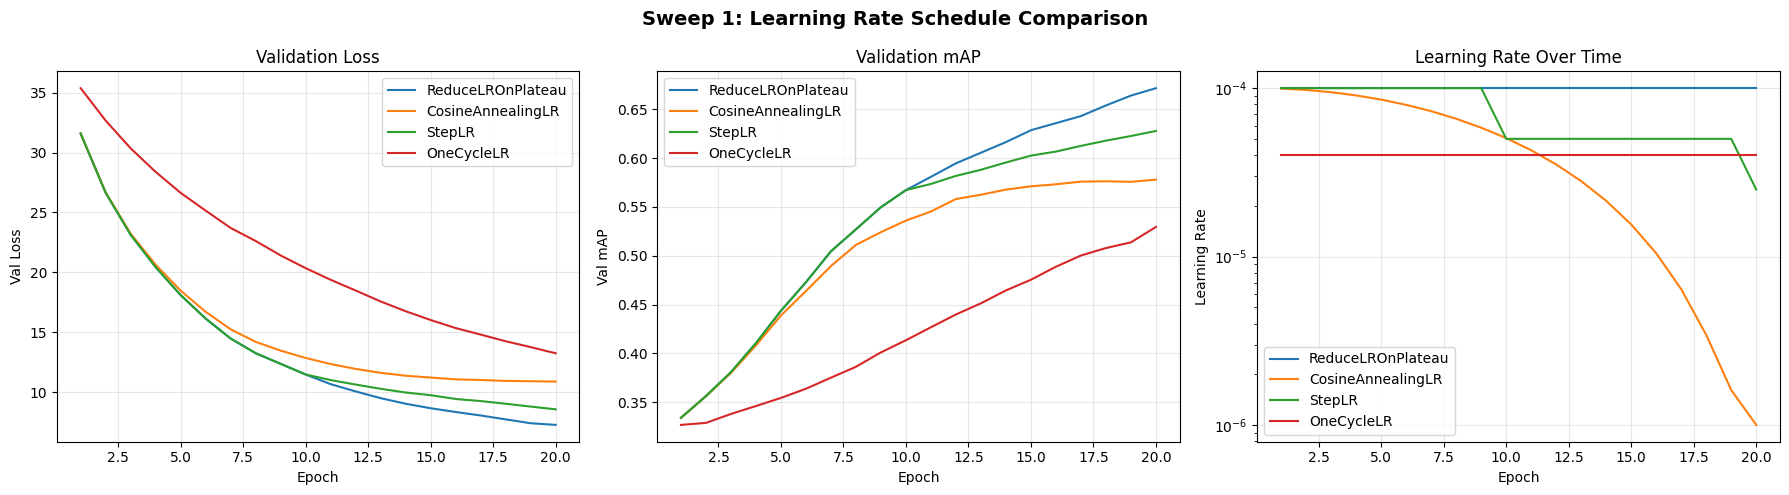

In [14]:
# Visualize Sweep 1 results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Sweep 1: Learning Rate Schedule Comparison", fontsize=14, fontweight='bold')

for r in sweep1_results:
    label = r['config_overrides']['scheduler_name']
    epochs = range(1, len(r['history']['train_loss']) + 1)
    axes[0].plot(epochs, r['history']['val_loss'], label=label)
    axes[1].plot(epochs, r['history']['val_map'], label=label)
    axes[2].plot(epochs, r['history']['lr'], label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss'); axes[0].set_title('Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val mAP'); axes[1].set_title('Validation mAP')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate'); axes[2].set_title('Learning Rate Over Time')
axes[2].legend(); axes[2].grid(True, alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'sweep1_lr_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sweep 2: Optimizer Comparison

Compare different optimizers while keeping all other hyperparameters at baseline values. Learning rates are adjusted per optimizer following common defaults.

| Optimizer | LR | Description |
|-----------|-----|-------------|
| AdamW | 1e-4 | Adam with decoupled weight decay (baseline) |
| Adam | 1e-4 | Standard Adam |
| SGD | 1e-2 | SGD with momentum 0.9 (needs higher LR) |
| Muon | 2e-2 | Momentum with Newton-Schulz orthogonalization |

In [15]:
# ── Sweep 2: Optimizer Comparison ──
print("=" * 70)
print("SWEEP 2: Optimizer Comparison")
print("=" * 70)

optimizer_configs = [
    {"optimizer_name": "AdamW", "learning_rate": 1e-4},
    {"optimizer_name": "Adam",  "learning_rate": 1e-4},
    {"optimizer_name": "SGD",   "learning_rate": 1e-2},
    {"optimizer_name": "Muon",  "learning_rate": 2e-2},
]

sweep2_results = []
for i, overrides in enumerate(optimizer_configs):
    name = f"optimizer-{overrides['optimizer_name']}-lr{overrides['learning_rate']}"
    print(f"\n[{i+1}/{len(optimizer_configs)}] Running: {name}")
    result = run_single_experiment(
        experiment_name=name,
        sweep_group="optimizer",
        config_overrides=overrides,
        train_embeddings=baseline_train_embeddings,
        train_labels=train_data['label_encoded'].values,
        val_embeddings=baseline_val_embeddings,
        val_labels_gt=val_data['ground_truth'].values,
        val_labels_encoded=val_data['label_encoded'].values,
        num_classes=num_classes,
        megadescriptor_dim=megadescriptor_dim,
        device=device,
    )
    sweep2_results.append(result)

print("\n" + "=" * 70)
print("SWEEP 2 RESULTS: Optimizer Comparison")
print("-" * 70)
for r in sorted(sweep2_results, key=lambda x: x['best_val_map'], reverse=True):
    print(f"  {r['experiment_name']:40s} → mAP: {r['best_val_map']:.4f}  (epoch {r['best_epoch']}/{r['total_epochs']})")

best_optimizer = max(sweep2_results, key=lambda x: x['best_val_map'])
print(f"\n  ★ Best optimizer: {best_optimizer['config_overrides']['optimizer_name']} (mAP: {best_optimizer['best_val_map']:.4f})")

SWEEP 2: Optimizer Comparison

[1/4] Running: optimizer-AdamW-lr0.0001


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201624-jt6uz7lx
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run optimizer-AdamW-lr0.0001
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/jt6uz7lx
wandb: updating run metadata
wandb: updating run metadata; uploading wandb-summary.json
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇███
wandb:      val_loss █▇▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 7.29186
wandb:  best_val_mAP 0.67156
wandb:         epoc

  [optimizer-AdamW-lr0.0001] Best mAP: 0.6716 (epoch 20)

[2/4] Running: optimizer-Adam-lr0.0001


wandb: setting up run ip8ke59n
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201632-ip8ke59n
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run optimizer-Adam-lr0.0001
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/ip8ke59n
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇███
wandb:      val_loss █▇▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 7.29187
wandb:  best_val_mAP 0.67191
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  tota

  [optimizer-Adam-lr0.0001] Best mAP: 0.6719 (epoch 20)

[3/4] Running: optimizer-SGD-lr0.01


wandb: setting up run b0la0x5b
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201639-b0la0x5b
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run optimizer-SGD-lr0.01
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/b0la0x5b
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate █████████████▁▁▁▁▁▁▁
wandb:     train_acc ▁▄▅▆▆▇▇▇▇▇▇█████████
wandb:    train_loss █▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▄▅▆▇▇▇█████████████
wandb:      val_loss █▄▄▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_map ▁▄▅▆▇▇██████████████
wandb: 
wandb: Run summary:
wandb:    best_epoch 15
wandb: best_val_loss 4.78774
wandb:  best_val_mAP 0.78492
wandb:         epoch 20
wandb: learning_rate 0.005
wandb:  total_ep

  [optimizer-SGD-lr0.01] Best mAP: 0.7849 (epoch 15)

[4/4] Running: optimizer-Muon-lr0.02


wandb: setting up run r5nhvyqf
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201646-r5nhvyqf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run optimizer-Muon-lr0.02
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/r5nhvyqf
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▂▂▃▄▄▅▅▆▇▇█
wandb: learning_rate ██████████▁▁
wandb:     train_acc ▁▄▆▇▇███████
wandb:    train_loss █▄▂▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▆▇▇████████
wandb:      val_loss █▃▂▁▁▁▁▁▁▁▂▁
wandb:       val_map ▁▆▇█████████
wandb: 
wandb: Run summary:
wandb:    best_epoch 5
wandb: best_val_loss 4.78423
wandb:  best_val_mAP 0.7934
wandb:         epoch 12
wandb: learning_rate 0.01
wandb:  total_epochs 12
wandb:     train_acc 92.61214
wandb:    train_loss

  [optimizer-Muon-lr0.02] Best mAP: 0.7934 (epoch 5)

SWEEP 2 RESULTS: Optimizer Comparison
----------------------------------------------------------------------
  optimizer-Muon-lr0.02                    → mAP: 0.7934  (epoch 5/12)
  optimizer-SGD-lr0.01                     → mAP: 0.7849  (epoch 15/20)
  optimizer-Adam-lr0.0001                  → mAP: 0.6719  (epoch 20/20)
  optimizer-AdamW-lr0.0001                 → mAP: 0.6716  (epoch 20/20)

  ★ Best optimizer: Muon (mAP: 0.7934)


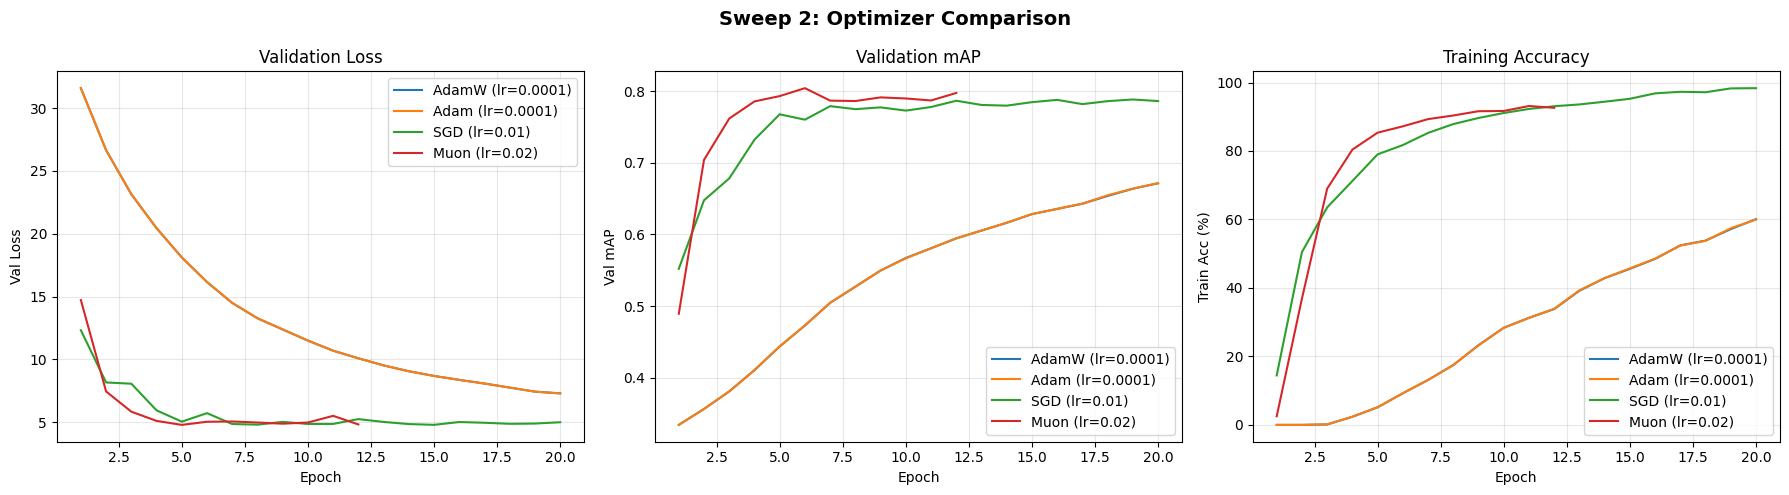

In [16]:
# Visualize Sweep 2 results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Sweep 2: Optimizer Comparison", fontsize=14, fontweight='bold')

for r in sweep2_results:
    label = f"{r['config_overrides']['optimizer_name']} (lr={r['config_overrides']['learning_rate']})"
    epochs = range(1, len(r['history']['train_loss']) + 1)
    axes[0].plot(epochs, r['history']['val_loss'], label=label)
    axes[1].plot(epochs, r['history']['val_map'], label=label)
    axes[2].plot(epochs, r['history']['train_acc'], label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss'); axes[0].set_title('Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val mAP'); axes[1].set_title('Validation mAP')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train Acc (%)'); axes[2].set_title('Training Accuracy')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'sweep2_optimizers.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sweep 3: Embedding Dimension & Hidden Layer Sizes

Vary the projection head dimensions to find the optimal embedding space size.

| Config | Hidden Dim | Embedding Dim | Notes |
|--------|-----------|---------------|-------|
| small | 256 | 128 | Compact representation |
| baseline | 512 | 256 | Baseline default |
| medium | 768 | 384 | Larger intermediate |
| large | 1024 | 512 | High-capacity projection |
| wide-shallow | 1024 | 128 | Wide hidden, compact embedding |

In [17]:
# ── Sweep 3: Embedding Dimension & Hidden Layer Sizes ──
print("=" * 70)
print("SWEEP 3: Embedding & Hidden Dimensions")
print("=" * 70)

dimension_configs = [
    {"embedding_dim": 128, "hidden_dim": 256},
    {"embedding_dim": 256, "hidden_dim": 512},   # baseline
    {"embedding_dim": 384, "hidden_dim": 768},
    {"embedding_dim": 512, "hidden_dim": 1024},
    {"embedding_dim": 128, "hidden_dim": 1024},   # wide hidden, compact embedding
]

sweep3_results = []
for i, overrides in enumerate(dimension_configs):
    name = f"dim-h{overrides['hidden_dim']}-e{overrides['embedding_dim']}"
    print(f"\n[{i+1}/{len(dimension_configs)}] Running: {name}")
    result = run_single_experiment(
        experiment_name=name,
        sweep_group="dimensions",
        config_overrides=overrides,
        train_embeddings=baseline_train_embeddings,
        train_labels=train_data['label_encoded'].values,
        val_embeddings=baseline_val_embeddings,
        val_labels_gt=val_data['ground_truth'].values,
        val_labels_encoded=val_data['label_encoded'].values,
        num_classes=num_classes,
        megadescriptor_dim=megadescriptor_dim,
        device=device,
    )
    sweep3_results.append(result)

print("\n" + "=" * 70)
print("SWEEP 3 RESULTS: Embedding & Hidden Dimensions")
print("-" * 70)
for r in sorted(sweep3_results, key=lambda x: x['best_val_map'], reverse=True):
    print(f"  {r['experiment_name']:40s} → mAP: {r['best_val_map']:.4f}  (epoch {r['best_epoch']}/{r['total_epochs']})")

best_dims = max(sweep3_results, key=lambda x: x['best_val_map'])
print(f"\n  ★ Best dimensions: hidden={best_dims['config_overrides']['hidden_dim']}, "
      f"embedding={best_dims['config_overrides']['embedding_dim']} (mAP: {best_dims['best_val_map']:.4f})")

SWEEP 3: Embedding & Hidden Dimensions

[1/5] Running: dim-h256-e128


wandb: setting up run v524sjkk
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201724-v524sjkk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dim-h256-e128
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/v524sjkk
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▁▁▂▂▂▃▃▄▄▅▆▆▇▇██
wandb:    train_loss █▇▆▆▅▅▄▄▃▃▃▃▂▂▂▂▁▁▁▁
wandb:       val_acc ▁▁▁▂▂▂▃▃▄▄▅▅▆▆▇▇▇▇██
wandb:      val_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁
wandb:       val_map ▁▁▂▂▃▃▄▄▄▅▅▆▆▆▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 10.68518
wandb:  best_val_mAP 0.57183
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 

  [dim-h256-e128] Best mAP: 0.5718 (epoch 20)

[2/5] Running: dim-h512-e256


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201732-uvke1xib
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dim-h512-e256
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/uvke1xib
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▂▂▃▃▄▄▅▅▆▆▆▇▇▇██
wandb:    train_loss █▇▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_acc ▁▁▂▂▃▃▄▅▅▆▆▆▇▇▇▇▇███
wandb:      val_loss █▇▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 7.29186
wandb:  best_val_mAP 0.67156
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 20
wandb:     train_acc 60.09235

  [dim-h512-e256] Best mAP: 0.6716 (epoch 20)

[3/5] Running: dim-h768-e384


...

  [dim-h768-e384] Best mAP: 0.7071 (epoch 20)

[4/5] Running: dim-h1024-e512


wandb: setting up run getesyni
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201746-getesyni
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dim-h1024-e512
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/getesyni
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▂▂▃▃▄▅▅▆▆▆▆▇▇▇▇███
wandb:    train_loss █▇▅▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_acc ▁▂▃▄▅▅▆▆▇▇▇▇▇▇██████
wandb:      val_loss █▆▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_map ▁▂▃▃▄▅▅▆▆▆▆▇▇▇▇▇████
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 5.32177
wandb:  best_val_mAP 0.756
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb: 

  [dim-h1024-e512] Best mAP: 0.7560 (epoch 20)

[5/5] Running: dim-h1024-e128


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201754-4s21eien
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dim-h1024-e128
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/4s21eien
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▂▂▃▄▄▅▅▆▆▆▇▇▇▇████
wandb:    train_loss █▆▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▂▃▄▅▅▆▆▇▇▇▇▇▇██████
wandb:      val_loss █▆▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb:       val_map ▁▂▃▄▄▅▅▆▆▆▇▇▇▇██████
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 5.57473
wandb:  best_val_mAP 0.7536
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 20
wandb:     train_acc 76.71504

  [dim-h1024-e128] Best mAP: 0.7536 (epoch 20)

SWEEP 3 RESULTS: Embedding & Hidden Dimensions
----------------------------------------------------------------------
  dim-h1024-e512                           → mAP: 0.7560  (epoch 20/20)
  dim-h1024-e128                           → mAP: 0.7536  (epoch 20/20)
  dim-h768-e384                            → mAP: 0.7071  (epoch 20/20)
  dim-h512-e256                            → mAP: 0.6716  (epoch 20/20)
  dim-h256-e128                            → mAP: 0.5718  (epoch 20/20)

  ★ Best dimensions: hidden=1024, embedding=512 (mAP: 0.7560)


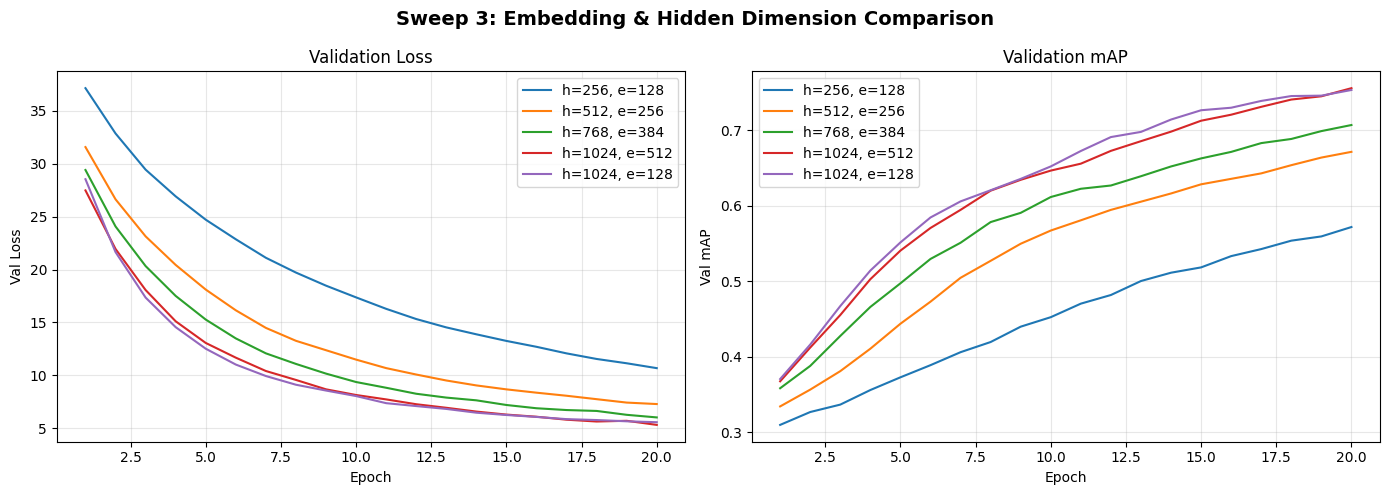

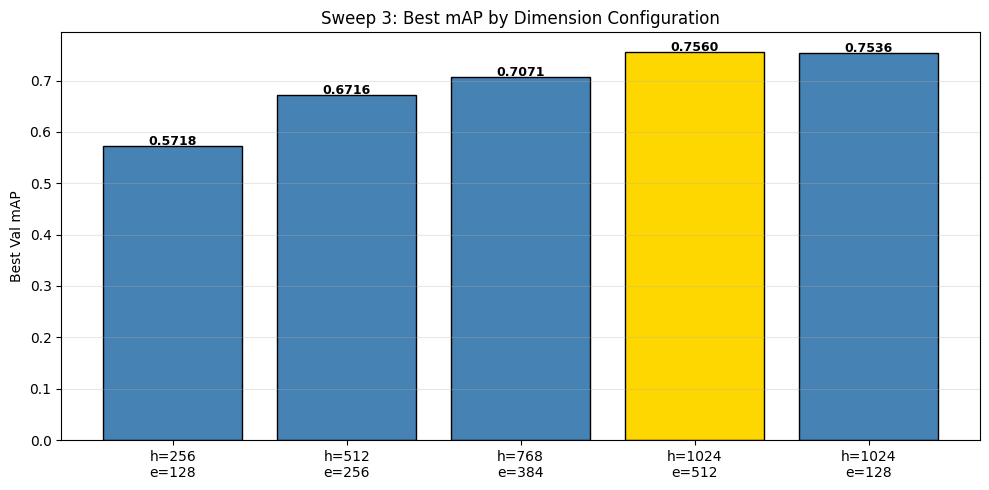

In [18]:
# Visualize Sweep 3 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sweep 3: Embedding & Hidden Dimension Comparison", fontsize=14, fontweight='bold')

for r in sweep3_results:
    label = f"h={r['config_overrides']['hidden_dim']}, e={r['config_overrides']['embedding_dim']}"
    epochs = range(1, len(r['history']['train_loss']) + 1)
    axes[0].plot(epochs, r['history']['val_loss'], label=label)
    axes[1].plot(epochs, r['history']['val_map'], label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss'); axes[0].set_title('Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val mAP'); axes[1].set_title('Validation mAP')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'sweep3_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart of best mAP per config
fig, ax = plt.subplots(figsize=(10, 5))
names = [f"h={r['config_overrides']['hidden_dim']}\ne={r['config_overrides']['embedding_dim']}" for r in sweep3_results]
maps = [r['best_val_map'] for r in sweep3_results]
colors = ['steelblue' if r != best_dims else 'gold' for r in sweep3_results]
ax.bar(names, maps, color=colors, edgecolor='black')
ax.set_ylabel('Best Val mAP')
ax.set_title('Sweep 3: Best mAP by Dimension Configuration')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(maps):
    ax.text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'sweep3_dimensions_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Sweep 4: ArcFace Margin & Scale

The ArcFace loss has two critical hyperparameters:
- **margin (m)**: Angular margin added to the ground truth class (larger = harder training, potentially better separation)
- **scale (s)**: Feature scale that controls softmax sharpness (larger = sharper probability distribution)

| Config | Margin | Scale | Margin (degrees) |
|--------|--------|-------|-------------------|
| m0.3-s32 | 0.3 | 32 | 17.2° |
| m0.3-s64 | 0.3 | 64 | 17.2° |
| m0.5-s32 | 0.5 | 32 | 28.6° |
| m0.5-s64 | 0.5 | 64 | 28.6° (baseline) |
| m0.5-s80 | 0.5 | 80 | 28.6° |
| m0.7-s64 | 0.7 | 64 | 40.1° |
| m0.7-s80 | 0.7 | 80 | 40.1° |
| m1.0-s64 | 1.0 | 64 | 57.3° |

In [19]:
# ── Sweep 4: ArcFace Margin & Scale ──
print("=" * 70)
print("SWEEP 4: ArcFace Margin & Scale")
print("=" * 70)

arcface_configs = [
    {"arcface_margin": 0.3, "arcface_scale": 32.0},
    {"arcface_margin": 0.3, "arcface_scale": 64.0},
    {"arcface_margin": 0.5, "arcface_scale": 32.0},
    {"arcface_margin": 0.5, "arcface_scale": 64.0},   # baseline
    {"arcface_margin": 0.5, "arcface_scale": 80.0},
    {"arcface_margin": 0.7, "arcface_scale": 64.0},
    {"arcface_margin": 0.7, "arcface_scale": 80.0},
    {"arcface_margin": 1.0, "arcface_scale": 64.0},
]

sweep4_results = []
for i, overrides in enumerate(arcface_configs):
    name = f"arcface-m{overrides['arcface_margin']}-s{int(overrides['arcface_scale'])}"
    print(f"\n[{i+1}/{len(arcface_configs)}] Running: {name}")
    result = run_single_experiment(
        experiment_name=name,
        sweep_group="arcface",
        config_overrides=overrides,
        train_embeddings=baseline_train_embeddings,
        train_labels=train_data['label_encoded'].values,
        val_embeddings=baseline_val_embeddings,
        val_labels_gt=val_data['ground_truth'].values,
        val_labels_encoded=val_data['label_encoded'].values,
        num_classes=num_classes,
        megadescriptor_dim=megadescriptor_dim,
        device=device,
    )
    sweep4_results.append(result)

print("\n" + "=" * 70)
print("SWEEP 4 RESULTS: ArcFace Margin & Scale")
print("-" * 70)
for r in sorted(sweep4_results, key=lambda x: x['best_val_map'], reverse=True):
    print(f"  {r['experiment_name']:40s} → mAP: {r['best_val_map']:.4f}  (epoch {r['best_epoch']}/{r['total_epochs']})")

best_arcface = max(sweep4_results, key=lambda x: x['best_val_map'])
print(f"\n  ★ Best ArcFace: margin={best_arcface['config_overrides']['arcface_margin']}, "
      f"scale={best_arcface['config_overrides']['arcface_scale']} (mAP: {best_arcface['best_val_map']:.4f})")

SWEEP 4: ArcFace Margin & Scale

[1/8] Running: arcface-m0.3-s32


wandb: setting up run hds7dyni
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201802-hds7dyni
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run arcface-m0.3-s32
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/hds7dyni
wandb: updating run metadata
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▂▂▃▄▄▅▅▆▆▆▇▇▇▇▇███
wandb:    train_loss █▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_acc ▁▂▃▄▅▅▆▆▇▇▇▇▇███████
wandb:      val_loss █▆▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:       val_map ▁▂▂▃▃▄▅▅▅▆▆▆▆▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 19
wandb: best_val_loss 1.98562
wandb:  best_val_mAP 0.6766
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs

  [arcface-m0.3-s32] Best mAP: 0.6766 (epoch 19)

[2/8] Running: arcface-m0.3-s64


wandb: setting up run k4sex5fi
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201809-k4sex5fi
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run arcface-m0.3-s64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/k4sex5fi
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▂▂▃▃▄▄▅▆▆▆▇▇▇▇▇███
wandb:    train_loss █▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
wandb:       val_acc ▁▂▃▄▅▅▆▆▆▇▇▇▇▇██████
wandb:      val_loss █▆▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▄▅▅▆▆▆▆▇▇▇▇███
wandb: 
wandb: Run summary:
wandb:    best_epoch 19
wandb: best_val_loss 3.88938
wandb:  best_val_mAP 0.65674
wandb:         epoch 20
wandb: learning_rate 0.0001
wan

  [arcface-m0.3-s64] Best mAP: 0.6567 (epoch 19)

[3/8] Running: arcface-m0.5-s32


...

  [arcface-m0.7-s64] Best mAP: 0.6543 (epoch 20)

[7/8] Running: arcface-m0.7-s80


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201844-1vcbalz1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run arcface-m0.7-s80
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/1vcbalz1
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▁▁▂▂▂▃▃▄▄▅▅▆▆▇▇█
wandb:    train_loss █▇▇▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁
wandb:       val_acc ▁▁▁▁▂▂▃▃▄▄▅▆▆▆▇▇▇███
wandb:      val_loss █▇▆▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:       val_map ▁▁▂▃▃▄▅▅▅▆▆▆▇▇▇▇████
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 14.84562
wandb:  best_val_mAP 0.65156
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 20
wandb:   

  [arcface-m0.7-s80] Best mAP: 0.6516 (epoch 20)

[8/8] Running: arcface-m1.0-s64


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201851-dyq4h6v9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run arcface-m1.0-s64
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/dyq4h6v9
wandb: updating run metadata
wandb: uploading history steps 0-19, summary
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     train_acc ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆█
wandb:    train_loss █▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁
wandb:       val_acc ▁▁▁▁▁▁▁▂▂▃▃▄▅▅▆▆▆▇██
wandb:      val_loss █▇▇▆▆▅▅▄▄▄▃▃▂▂▂▂▂▁▁▁
wandb:       val_map ▁▁▂▃▃▄▄▅▆▆▆▇▇▇▇█████
wandb: 
wandb: Run summary:
wandb:    best_epoch 20
wandb: best_val_loss 21.54895
wandb:  best_val_mAP 0.62591
wandb:         epoch 20
wandb: learning_rate 0.0001
wandb:  total_epochs 20
wandb:   

  [arcface-m1.0-s64] Best mAP: 0.6259 (epoch 20)

SWEEP 4 RESULTS: ArcFace Margin & Scale
----------------------------------------------------------------------
  arcface-m0.5-s32                         → mAP: 0.6848  (epoch 20/20)
  arcface-m0.3-s32                         → mAP: 0.6766  (epoch 19/20)
  arcface-m0.5-s64                         → mAP: 0.6716  (epoch 20/20)
  arcface-m0.5-s80                         → mAP: 0.6658  (epoch 20/20)
  arcface-m0.3-s64                         → mAP: 0.6567  (epoch 19/20)
  arcface-m0.7-s64                         → mAP: 0.6543  (epoch 20/20)
  arcface-m0.7-s80                         → mAP: 0.6516  (epoch 20/20)
  arcface-m1.0-s64                         → mAP: 0.6259  (epoch 20/20)

  ★ Best ArcFace: margin=0.5, scale=32.0 (mAP: 0.6848)


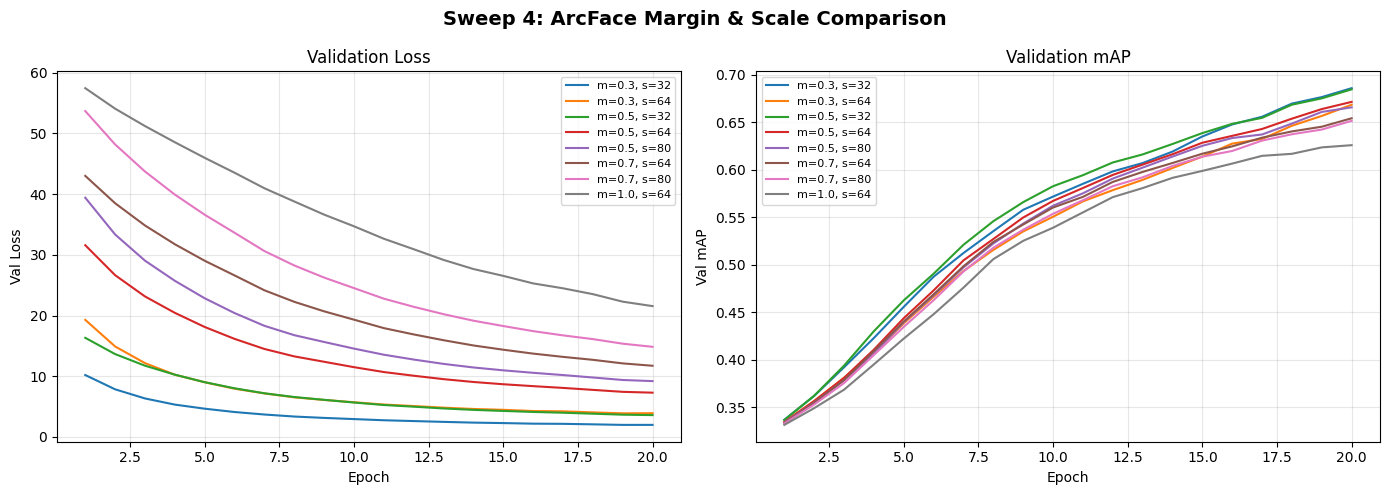

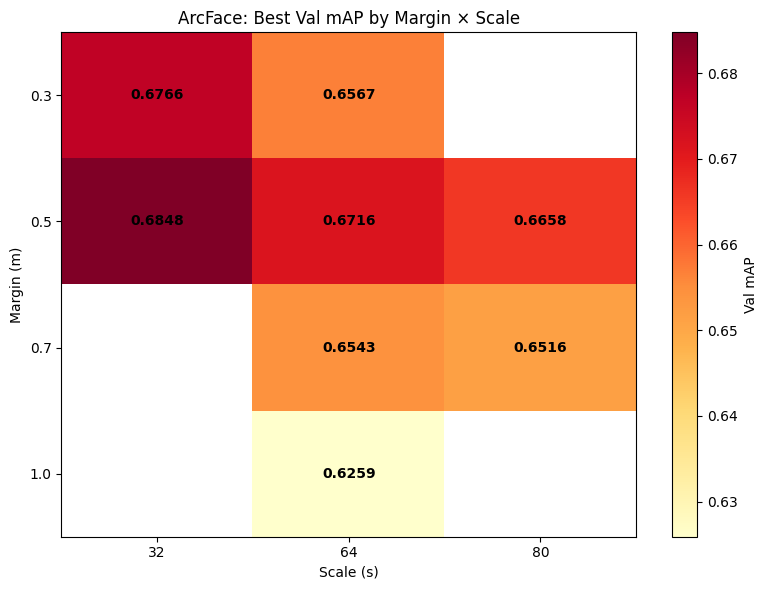

In [20]:
# Visualize Sweep 4 results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sweep 4: ArcFace Margin & Scale Comparison", fontsize=14, fontweight='bold')

for r in sweep4_results:
    label = f"m={r['config_overrides']['arcface_margin']}, s={int(r['config_overrides']['arcface_scale'])}"
    epochs = range(1, len(r['history']['train_loss']) + 1)
    axes[0].plot(epochs, r['history']['val_loss'], label=label)
    axes[1].plot(epochs, r['history']['val_map'], label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss'); axes[0].set_title('Validation Loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val mAP'); axes[1].set_title('Validation mAP')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'sweep4_arcface.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap: margin x scale → best mAP
margins = sorted(set(r['config_overrides']['arcface_margin'] for r in sweep4_results))
scales = sorted(set(r['config_overrides']['arcface_scale'] for r in sweep4_results))

heatmap_data = np.full((len(margins), len(scales)), np.nan)
for r in sweep4_results:
    mi = margins.index(r['config_overrides']['arcface_margin'])
    si = scales.index(r['config_overrides']['arcface_scale'])
    heatmap_data[mi, si] = r['best_val_map']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(scales)))
ax.set_xticklabels([f"{s:.0f}" for s in scales])
ax.set_yticks(range(len(margins)))
ax.set_yticklabels([f"{m}" for m in margins])
ax.set_xlabel('Scale (s)')
ax.set_ylabel('Margin (m)')
ax.set_title('ArcFace: Best Val mAP by Margin × Scale')

# Annotate cells
for i in range(len(margins)):
    for j in range(len(scales)):
        if not np.isnan(heatmap_data[i, j]):
            ax.text(j, i, f"{heatmap_data[i, j]:.4f}", ha='center', va='center',
                    fontsize=10, fontweight='bold', color='black')

plt.colorbar(im, label='Val mAP')
plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'sweep4_arcface_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Overall Results Summary

Combine results from all sweeps and identify the best configuration for the final full-length training run.

In [21]:
# ── Overall Results Summary ──
all_results = sweep1_results + sweep2_results + sweep3_results + sweep4_results

print("=" * 80)
print("OVERALL HYPERPARAMETER SWEEP RESULTS")
print("=" * 80)

# Group by sweep
for group_name, group_results in [
    ("LR Schedule", sweep1_results),
    ("Optimizer", sweep2_results),
    ("Dimensions", sweep3_results),
    ("ArcFace m/s", sweep4_results),
]:
    best = max(group_results, key=lambda x: x['best_val_map'])
    print(f"\n{group_name}:")
    for r in sorted(group_results, key=lambda x: x['best_val_map'], reverse=True):
        marker = "★" if r == best else " "
        print(f"  {marker} {r['experiment_name']:40s} → mAP: {r['best_val_map']:.4f}")

# Overall best
overall_best = max(all_results, key=lambda x: x['best_val_map'])
print(f"\n{'='*80}")
print(f"OVERALL BEST: {overall_best['experiment_name']}")
print(f"  mAP: {overall_best['best_val_map']:.4f}")
print(f"  Config: {overall_best['config_overrides']}")

# Compose the best combined configuration
best_combined_config = {
    "scheduler_name": best_lr_schedule['config_overrides'].get('scheduler_name', 'ReduceLROnPlateau'),
    "optimizer_name": best_optimizer['config_overrides'].get('optimizer_name', 'AdamW'),
    "learning_rate": best_optimizer['config_overrides'].get('learning_rate', 1e-4),
    "embedding_dim": best_dims['config_overrides'].get('embedding_dim', 256),
    "hidden_dim": best_dims['config_overrides'].get('hidden_dim', 512),
    "arcface_margin": best_arcface['config_overrides'].get('arcface_margin', 0.5),
    "arcface_scale": best_arcface['config_overrides'].get('arcface_scale', 64.0),
}

print(f"\n{'='*80}")
print(f"BEST COMBINED CONFIGURATION (winners from each sweep):")
for k, v in best_combined_config.items():
    print(f"  {k}: {v}")

OVERALL HYPERPARAMETER SWEEP RESULTS

LR Schedule:
  ★ lr-schedule-ReduceLROnPlateau            → mAP: 0.6716
    lr-schedule-StepLR                       → mAP: 0.6277
    lr-schedule-CosineAnnealingLR            → mAP: 0.5779
    lr-schedule-OneCycleLR                   → mAP: 0.5294

Optimizer:
  ★ optimizer-Muon-lr0.02                    → mAP: 0.7934
    optimizer-SGD-lr0.01                     → mAP: 0.7849
    optimizer-Adam-lr0.0001                  → mAP: 0.6719
    optimizer-AdamW-lr0.0001                 → mAP: 0.6716

Dimensions:
  ★ dim-h1024-e512                           → mAP: 0.7560
    dim-h1024-e128                           → mAP: 0.7536
    dim-h768-e384                            → mAP: 0.7071
    dim-h512-e256                            → mAP: 0.6716
    dim-h256-e128                            → mAP: 0.5718

ArcFace m/s:
  ★ arcface-m0.5-s32                         → mAP: 0.6848
    arcface-m0.3-s32                         → mAP: 0.6766
    arcface-m0.5-s64     

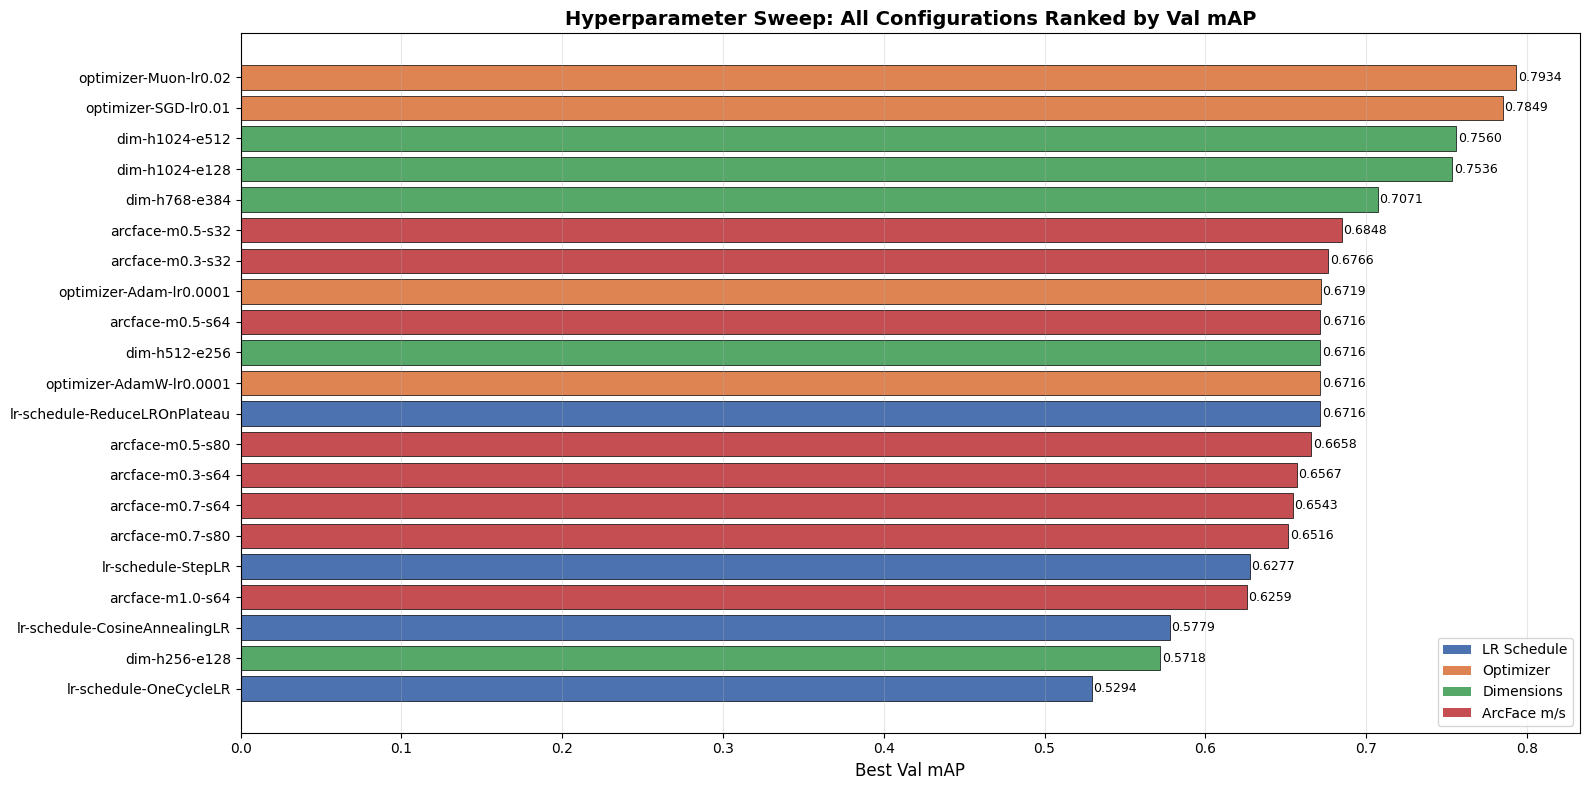

In [22]:
# ── Summary Bar Chart ──
fig, ax = plt.subplots(figsize=(16, 8))

# Sort all results by mAP
sorted_results = sorted(all_results, key=lambda x: x['best_val_map'])
names = [r['experiment_name'] for r in sorted_results]
maps = [r['best_val_map'] for r in sorted_results]

# Color by sweep group
group_colors = {
    "lr_schedule": "#4C72B0",
    "optimizer": "#DD8452",
    "dimensions": "#55A868",
    "arcface": "#C44E52",
}
colors = [group_colors.get(r['sweep_group'], 'gray') for r in sorted_results]

bars = ax.barh(names, maps, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Best Val mAP', fontsize=12)
ax.set_title('Hyperparameter Sweep: All Configurations Ranked by Val mAP', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, maps):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=group_colors["lr_schedule"], label="LR Schedule"),
    Patch(facecolor=group_colors["optimizer"], label="Optimizer"),
    Patch(facecolor=group_colors["dimensions"], label="Dimensions"),
    Patch(facecolor=group_colors["arcface"], label="ArcFace m/s"),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(base_config["checkpoint_dir"] / 'all_sweeps_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Full Training with Best Combined Configuration

Train the best combined configuration (winners from each sweep) for the full number of epochs, with checkpointing and submission generation.

In [23]:
# ── Full Training with Best Combined Configuration ──
print("=" * 70)
print("FULL TRAINING: Best Combined Configuration")
print("=" * 70)
print(f"Configuration:")
for k, v in best_combined_config.items():
    print(f"  {k}: {v}")
print(f"  Epochs: {FULL_TRAIN_EPOCHS}")

# Seed
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# W&B run
run = wandb.init(
    project=WANDB_PROJECT,
    group="hyperopt-best",
    config={**{k: str(v) if isinstance(v, Path) else v for k, v in base_config.items()}, **best_combined_config},
    name="hyperopt-best-combined",
    reinit=True,
)

# Create model with best config
cfg = {**base_config, **best_combined_config}

model = ArcFaceModel(
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=cfg["embedding_dim"],
    hidden_dim=cfg["hidden_dim"],
    margin=cfg["arcface_margin"],
    scale=cfg["arcface_scale"],
    dropout=cfg["dropout"],
).to(device)

# Dataloaders
train_dataset = EmbeddingDataset(baseline_train_embeddings, train_data['label_encoded'].values)
val_dataset = EmbeddingDataset(baseline_val_embeddings, val_data['label_encoded'].values)
train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=cfg["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()

optimizer_name = cfg.get("optimizer_name", "AdamW")
lr = cfg["learning_rate"]
wd = cfg["weight_decay"]

if optimizer_name == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
elif optimizer_name == "SGD":
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
elif optimizer_name == "AdamW":
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
elif optimizer_name == "Muon":
    optimizer = Muon(model.parameters(), lr=lr, momentum=0.95, weight_decay=wd)

scheduler_name = cfg.get("scheduler_name", "ReduceLROnPlateau")
if scheduler_name == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
elif scheduler_name == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FULL_TRAIN_EPOCHS, eta_min=1e-6)
elif scheduler_name == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
elif scheduler_name == "OneCycleLR":
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr * 10, epochs=FULL_TRAIN_EPOCHS, steps_per_epoch=len(train_loader)
    )

print(f"\nOptimizer: {optimizer_name}")
print(f"Scheduler: {scheduler_name}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

FULL TRAINING: Best Combined Configuration
Configuration:
  scheduler_name: ReduceLROnPlateau
  optimizer_name: Muon
  learning_rate: 0.02
  embedding_dim: 512
  hidden_dim: 1024
  arcface_margin: 0.5
  arcface_scale: 32.0
  Epochs: 50


wandb: setting up run 8o4ae0l5
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260304_201900-8o4ae0l5
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run hyperopt-best-combined
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/Jaguar-Re-identification-Challenge/runs/8o4ae0l5



Optimizer: Muon
Scheduler: ReduceLROnPlateau
Parameters: 2,117,632


In [24]:
# Full training loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': []}
best_val_loss = float('inf')
best_map = 0.0
patience_counter = 0
best_epoch = 0

print(f"\nStarting full training for {FULL_TRAIN_EPOCHS} epochs...")
print("=" * 70)

for epoch in range(FULL_TRAIN_EPOCHS):
    print(f"\nEpoch {epoch+1}/{FULL_TRAIN_EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    val_map = compute_validation_map(
        model, baseline_val_embeddings, val_data['ground_truth'].values, device
    )

    # Update scheduler
    if scheduler_name == "ReduceLROnPlateau":
        scheduler.step(val_loss)
    elif scheduler_name != "OneCycleLR":
        scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss, 'val_acc': val_acc,
        'val_map': val_map, 'learning_rate': current_lr,
    })

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
    print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_map = val_map
        best_epoch = epoch + 1
        patience_counter = 0

        checkpoint_path = cfg["checkpoint_dir"] / "arcface_best_hyperopt.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_map': val_map,
            'config': {k: str(v) if isinstance(v, Path) else v for k, v in cfg.items()},
            'label_encoder_classes': label_encoder.classes_.tolist(),
            'num_classes': num_classes,
        }, checkpoint_path)
        print(f"  [New best model saved]")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{cfg['patience']}")

    if patience_counter >= cfg['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")

wandb.run.summary["best_val_mAP"] = best_map
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = best_epoch
wandb.run.summary["total_epochs"] = len(history['train_loss'])


Starting full training for 50 epochs...

Epoch 1/50
  Train Loss: 13.7874 | Train Acc: 4.9%
  Val Loss:   6.6644 | Val Acc:   40.6%
  Val mAP:    0.5425 | LR: 2.00e-02
  [New best model saved]

Epoch 2/50
  Train Loss: 4.0467 | Train Acc: 52.6%
  Val Loss:   3.0637 | Val Acc:   75.7%
  Val mAP:    0.7390 | LR: 2.00e-02
  [New best model saved]

Epoch 3/50
  Train Loss: 1.0622 | Train Acc: 83.2%
  Val Loss:   2.5158 | Val Acc:   82.6%
  Val mAP:    0.7909 | LR: 2.00e-02
  [New best model saved]

Epoch 4/50
  Train Loss: 0.3495 | Train Acc: 92.0%
  Val Loss:   2.2549 | Val Acc:   86.5%
  Val mAP:    0.8017 | LR: 2.00e-02
  [New best model saved]

Epoch 5/50
  Train Loss: 0.2708 | Train Acc: 93.9%
  Val Loss:   2.2368 | Val Acc:   86.8%
  Val mAP:    0.7950 | LR: 2.00e-02
  [New best model saved]

Epoch 6/50
  Train Loss: 0.1735 | Train Acc: 96.2%
  Val Loss:   2.2363 | Val Acc:   86.5%
  Val mAP:    0.8050 | LR: 2.00e-02
  [New best model saved]

Epoch 7/50
  Train Loss: 0.2153 | Train 

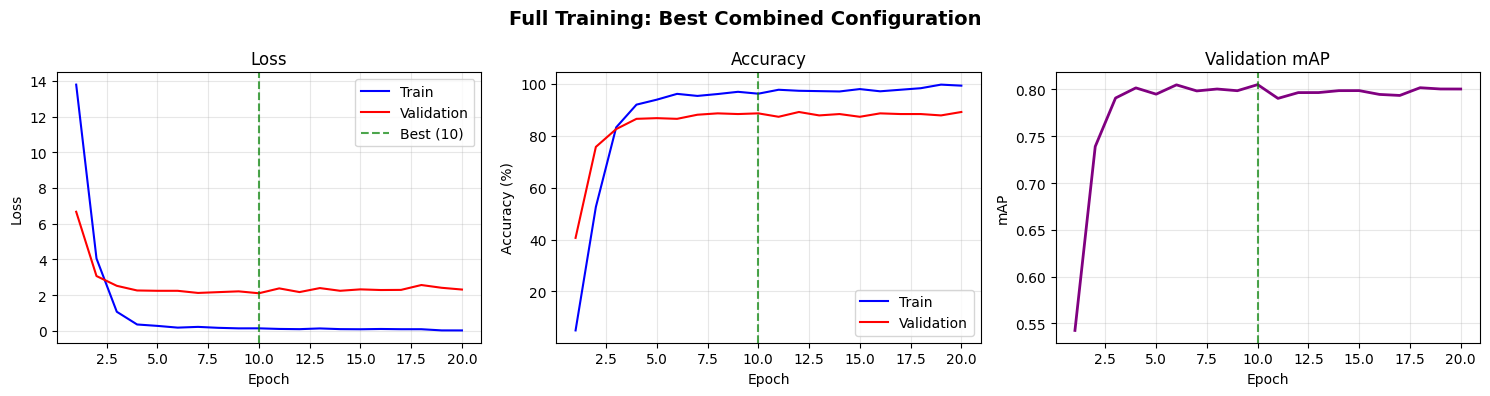

In [25]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Full Training: Best Combined Configuration", fontsize=14, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('mAP'); axes[2].set_title('Validation mAP')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(cfg["checkpoint_dir"] / 'full_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({"training_curves": wandb.Image(fig)})

## 13. Visualize Fine-tuned Embeddings

In [26]:
# Load best model
checkpoint = torch.load(cfg["checkpoint_dir"] / "arcface_best_hyperopt.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 10
  Val Loss: 2.0991
  Val mAP: 0.8052


In [27]:
# Extract fine-tuned embeddings
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_train_embeddings).to(device)
    finetuned_train_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1516, 512)
Mean L2 norm: 1.0000


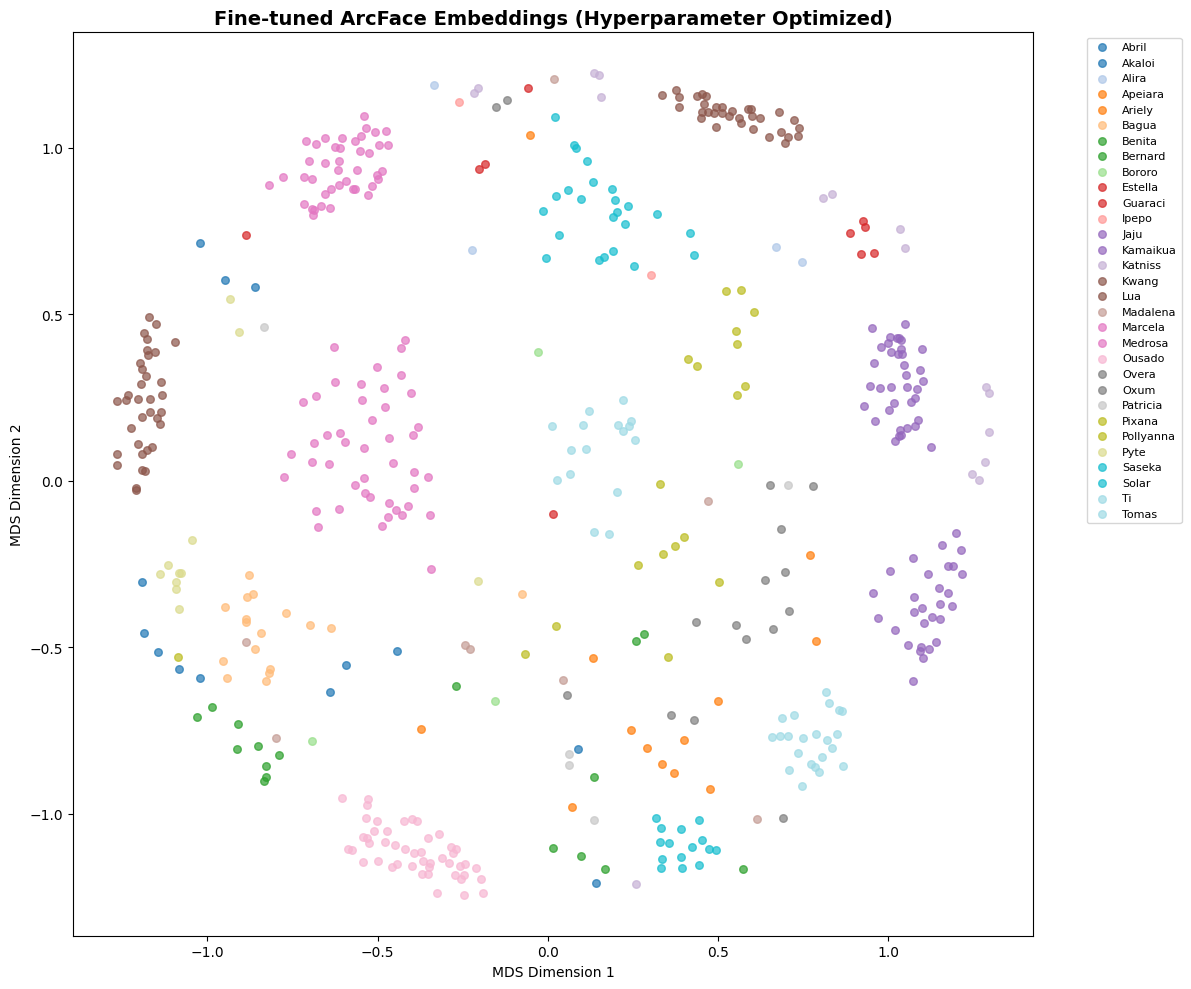

In [28]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    geodesic_dist = np.arccos(cos_sim)
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]

    dist_matrix = compute_geodesic_distances(embeddings)
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)

    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(12, 10))
    for label in unique_labels:
        mask = labels == label
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], c=[label_to_color[label]], label=label, alpha=0.7, s=30)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig


# Visualize
train_labels = train_data['ground_truth'].values
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings, train_labels,
    "Fine-tuned ArcFace Embeddings (Hyperparameter Optimized)"
)
plt.show()
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

## 14. Generate Competition Submission

In [29]:
# Load test data
test_pairs_df = pd.read_csv(cfg["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [30]:
# Get unique test images and extract embeddings
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

test_image_paths = [cfg["data_dir"] / "test" / "test" / filename for filename in test_images]

print(f"\nExtracting MegaDescriptor embeddings for test images...")
test_mega_embeddings = extract_embeddings(
    megadescriptor, test_image_paths, batch_size=cfg["batch_size"], desc="Test embeddings"
)

# Get fine-tuned test embeddings
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")

Unique test images: 371

Extracting MegaDescriptor embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Fine-tuned test embeddings shape: (371, 512)


In [31]:
# Compute similarities and create submission
img_to_embedding = {fn: emb for fn, emb in zip(test_images, test_finetuned_embeddings)}

print("Computing pairwise similarities...")
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

# Create submission
submission_df = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
print(f"\nSubmission DataFrame:")
print(submission_df.head(10))

# Verify format
sample_submission = pd.read_csv(cfg["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9971
  Mean: 0.0763
  Std: 0.1522

Submission DataFrame:
   row_id  similarity
0       0    0.754452
1       1    0.037523
2       2    0.070108
3       3    0.000000
4       4    0.071541
5       5    0.050166
6       6    0.106482
7       7    0.000000
8       8    0.000000
9       9    0.211081

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [32]:
# Save submission
submission_path = cfg["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: checkpoints_hyperopt/submission.csv
File size: 1807.9 KB


## 15. Save Artifacts and Finish

In [33]:
# Save model as W&B artifact
model_artifact = wandb.Artifact(
    name="arcface-model-hyperopt",
    type="model",
    description="ArcFace model with hyperparameter-optimized configuration"
)
model_artifact.add_file(str(cfg["checkpoint_dir"] / "arcface_best_hyperopt.pth"))
wandb.log_artifact(model_artifact)

print("Model artifact saved to W&B")

# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission-hyperopt",
    type="submission",
    description="Competition submission from hyperparameter-optimized model"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Model artifact saved to W&B
Submission artifact saved to W&B


In [34]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

wandb: uploading artifact arcface-model-hyperopt; uploading artifact submission-hyperopt; updating run metadata
wandb: uploading artifact arcface-model-hyperopt; uploading artifact submission-hyperopt
wandb: uploading summary, console lines 153-181
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: learning_rate ███████████████▁▁▁▁▁
wandb:     train_acc ▁▅▇▇████████████████
wandb:    train_loss █▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:       val_acc ▁▆▇█████████████████
wandb:      val_loss █▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁
wandb:       val_map ▁▆██████████████████
wandb: 
wandb: Run summary:
wandb:    best_epoch 10
wandb: best_val_loss 2.09912
wandb:  best_val_mAP 0.80519
wandb:         epoch 20
wandb: learning_rate 0.01
wandb:  total_epochs 20
wandb:     train_acc 99.34037
wandb:    train_loss 0.01624
wandb:       val_acc 89.18206
wandb:      val_loss 2.30738
wandb:            +1 ...
wandb: 
wandb: 🚀 View run hyperopt-best-combined at: https://wandb.ai/finnfreiheit/Jaguar-Re-identific

W&B run completed


## Summary

This notebook performed a **systematic hyperparameter analysis** on the baseline pipeline (MegaDescriptor + ArcFace):

### Sweeps Conducted
1. **Learning Rate Schedules** — ReduceLROnPlateau, CosineAnnealingLR, StepLR, OneCycleLR
2. **Optimizer Comparisons** — AdamW, Adam, SGD (momentum=0.9), Muon
3. **Embedding & Hidden Dimensions** — 5 configurations from (h=256, e=128) to (h=1024, e=512)
4. **ArcFace Margin & Scale** — 8 configurations: margin ∈ {0.3, 0.5, 0.7, 1.0}, scale ∈ {32, 64, 80}

### Methodology
- Each sweep configuration trained for 20 epochs (reduced from 50) for efficiency
- Best winners from each sweep combined into final configuration
- Final configuration trained for full 50 epochs with checkpointing

### Controlled Variables
- Same MegaDescriptor-L-384 backbone
- Same data (no augmentation)
- Same train/val split (stratified, seed=42)
- Same validation mAP computation
- Same W&B logging for comparison

### How to Compare
- W&B dashboard: filter by group `hyperopt-*` to see all sweep runs
- Compare `best_val_mAP` across groups
- Final model: group `hyperopt-best`, run `hyperopt-best-combined`
- Baseline comparison: `megadescriptor-arcface-local` or `megadescriptor-arcface-preaugmentation`